In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font size="6" color="red">ch.04 RNN_순환신경망</font></b>
- 데이터의 순서가 중요하거나, 시계열 데이터일 경우
- 활용분야 : 번역, 음성인식, 주가예측, 농수산물 가격예측
# 1. 문맥을 이용하여 모델 만들기

In [2]:
text = '''경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다'''
text1 = "겨울이 오는 날"

In [3]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()
t.fit_on_texts([text,text1])
encoding = t.texts_to_sequences([text,text1])
print(encoding)
print(t.word_index)

[[3, 4, 1, 5, 6, 7, 1, 8, 9, 1, 10, 2, 1, 11], [12, 2, 13]]
{'말이': 1, '오는': 2, '경마장에': 3, '있는': 4, '뛰고': 5, '있다': 6, '그의': 7, '법이다': 8, '가는': 9, '고와야': 10, '곱다': 11, '겨울이': 12, '날': 13}


In [4]:
t.texts_to_sequences(['경마장에 있는 말이 뛴다'])[0] # 무조건 리스트로 입력해야 함

[3, 4, 1]

In [5]:
text = '''경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다'''

In [6]:
t=Tokenizer()
t.fit_on_texts([text])
encoded = t.texts_to_sequences([text])[0]
print(encoded)
print(t.word_index)

[2, 3, 1, 4, 5, 6, 1, 7, 8, 1, 9, 10, 1, 11]
{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고와야': 9, '오는': 10, '곱다': 11}


In [7]:
for key, value in t.word_index.items():
    print(key,value)

말이 1
경마장에 2
있는 3
뛰고 4
있다 5
그의 6
법이다 7
가는 8
고와야 9
오는 10
곱다 11


In [8]:
# 텍스트를 학습시키기 위해, ['경마장에 있는'(2, 3), '경마장에 있는 말이'(2, 3, 1), ......]
sequences = []
for line in text.split('\n'):
    encoded = t.texts_to_sequences([line])[0]
    print('원문장 :', line, '| 인코딩된 문장 :', encoded)
    for i in range(0, len(encoded)-1): # 시작index
        for j in range(i+2, len(encoded)+1): # 끝나는 index + 1
            sequences.append(encoded[i:j])
# sequences, len(sequences)
print('sequences 와 해석')
for sequence in sequences:
    # print(sequences)
    for word_seq in sequence:
        for key, value in t.word_index.items():
            if word_seq == value:
                print('{}:{}'.format(word_seq, key),end= ' ')
                break
    print()

원문장 : 경마장에 있는 말이 뛰고 있다 | 인코딩된 문장 : [2, 3, 1, 4, 5]
원문장 : 그의 말이 법이다 | 인코딩된 문장 : [6, 1, 7]
원문장 : 가는 말이 고와야 오는 말이 곱다 | 인코딩된 문장 : [8, 1, 9, 10, 1, 11]
sequences 와 해석
2:경마장에 3:있는 
2:경마장에 3:있는 1:말이 
2:경마장에 3:있는 1:말이 4:뛰고 
2:경마장에 3:있는 1:말이 4:뛰고 5:있다 
3:있는 1:말이 
3:있는 1:말이 4:뛰고 
3:있는 1:말이 4:뛰고 5:있다 
1:말이 4:뛰고 
1:말이 4:뛰고 5:있다 
4:뛰고 5:있다 
6:그의 1:말이 
6:그의 1:말이 7:법이다 
1:말이 7:법이다 
8:가는 1:말이 
8:가는 1:말이 9:고와야 
8:가는 1:말이 9:고와야 10:오는 
8:가는 1:말이 9:고와야 10:오는 1:말이 
8:가는 1:말이 9:고와야 10:오는 1:말이 11:곱다 
1:말이 9:고와야 
1:말이 9:고와야 10:오는 
1:말이 9:고와야 10:오는 1:말이 
1:말이 9:고와야 10:오는 1:말이 11:곱다 
9:고와야 10:오는 
9:고와야 10:오는 1:말이 
9:고와야 10:오는 1:말이 11:곱다 
10:오는 1:말이 
10:오는 1:말이 11:곱다 
1:말이 11:곱다 


In [9]:
my_len = max([len(sequence) for sequence in sequences])

In [10]:
# sequences를 훈련가능하도록 6(my_len)개열로 조정
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(sequences = sequences,
                                maxlen = my_len,
                                padding='pre', # 상황에 맞게 특별한 규칙은 없음 
                                )

In [11]:
padded_sequences.shape, padded_sequences, type(padded_sequences)

((28, 6),
 array([[ 0,  0,  0,  0,  2,  3],
        [ 0,  0,  0,  2,  3,  1],
        [ 0,  0,  2,  3,  1,  4],
        [ 0,  2,  3,  1,  4,  5],
        [ 0,  0,  0,  0,  3,  1],
        [ 0,  0,  0,  3,  1,  4],
        [ 0,  0,  3,  1,  4,  5],
        [ 0,  0,  0,  0,  1,  4],
        [ 0,  0,  0,  1,  4,  5],
        [ 0,  0,  0,  0,  4,  5],
        [ 0,  0,  0,  0,  6,  1],
        [ 0,  0,  0,  6,  1,  7],
        [ 0,  0,  0,  0,  1,  7],
        [ 0,  0,  0,  0,  8,  1],
        [ 0,  0,  0,  8,  1,  9],
        [ 0,  0,  8,  1,  9, 10],
        [ 0,  8,  1,  9, 10,  1],
        [ 8,  1,  9, 10,  1, 11],
        [ 0,  0,  0,  0,  1,  9],
        [ 0,  0,  0,  1,  9, 10],
        [ 0,  0,  1,  9, 10,  1],
        [ 0,  1,  9, 10,  1, 11],
        [ 0,  0,  0,  0,  9, 10],
        [ 0,  0,  0,  9, 10,  1],
        [ 0,  0,  9, 10,  1, 11],
        [ 0,  0,  0,  0, 10,  1],
        [ 0,  0,  0, 10,  1, 11],
        [ 0,  0,  0,  0,  1, 11]]),
 numpy.ndarray)

In [12]:
# 독립변수(x)와 타겟변수(y)로 분리
X = padded_sequences[:, :-1]
y = padded_sequences[:,-1]
X.shape, y.shape

((28, 5), (28,))

In [13]:
# 단어갯수
vocab_size = len(t.word_index)
# x를 임베딩작업을 할 때 input_dim
input_dim = vocab_size + 1
input_dim

12

In [14]:
# 타겟변수(y)의 원핫인코딩
from tensorflow.keras.utils import to_categorical
Y = to_categorical(y, vocab_size+1)
Y

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.,

In [15]:
X.shape, Y.shape, vocab_size

((28, 5), (28, 12), 11)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# 모델 생성하기
model = Sequential()
# 원핫인코딩한 희소생렬을 임베딩 벡터로 변환(X=[0,8,1,9,10])
model.add(Embedding(input_dim = vocab_size + 1, # 임베딩층의 입력(원핫인코딩 dim)
                    output_dim = 10, # 임베딩층의 출력
                    input_length = X.shape[1] # 입력 데이터 길이
                   ))
model.add(SimpleRNN(32)) # SimpleRNN의 값은 Dense값 처럼 작성 시 원하는 값으로
model.add(Dense(12,activation='softmax'))
model.summary()
# 두번째 layer의 파라미터가 1376 = (10*32) + (32*32) + 32(bias)
# 3. 모델 학습설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy(원핫인코딩 자동으로)
              optimizer='adam',
              metrics=['accuracy'] # 평가지표
             )
# 4. 모델 학습하기
hist = model.fit(X,Y, epochs=300, verbose=2)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 5, 10)             120       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 32)                1376      
                                                                 
 dense_1 (Dense)             (None, 12)                396       
                                                                 
Total params: 1,892
Trainable params: 1,892
Non-trainable params: 0
_________________________________________________________________
Epoch 1/300
1/1 - 1s - loss: 2.4778 - accuracy: 0.2500 - 726ms/epoch - 726ms/step
Epoch 2/300
1/1 - 0s - loss: 2.4679 - accuracy: 0.2857 - 2ms/epoch - 2ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4582 - accuracy: 0.2500 - 4ms/epoch - 4ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4485 - accuracy: 0.2500 - 2ms/epoch - 2ms/step


Epoch 95/300
1/1 - 0s - loss: 1.1872 - accuracy: 0.5357 - 5ms/epoch - 5ms/step
Epoch 96/300
1/1 - 0s - loss: 1.1758 - accuracy: 0.5357 - 4ms/epoch - 4ms/step
Epoch 97/300
1/1 - 0s - loss: 1.1645 - accuracy: 0.5357 - 3ms/epoch - 3ms/step
Epoch 98/300
1/1 - 0s - loss: 1.1533 - accuracy: 0.5714 - 5ms/epoch - 5ms/step
Epoch 99/300
1/1 - 0s - loss: 1.1423 - accuracy: 0.5714 - 4ms/epoch - 4ms/step
Epoch 100/300
1/1 - 0s - loss: 1.1314 - accuracy: 0.5714 - 3ms/epoch - 3ms/step
Epoch 101/300
1/1 - 0s - loss: 1.1206 - accuracy: 0.5714 - 4ms/epoch - 4ms/step
Epoch 102/300
1/1 - 0s - loss: 1.1099 - accuracy: 0.5714 - 8ms/epoch - 8ms/step
Epoch 103/300
1/1 - 0s - loss: 1.0994 - accuracy: 0.5714 - 2ms/epoch - 2ms/step
Epoch 104/300
1/1 - 0s - loss: 1.0890 - accuracy: 0.5714 - 7ms/epoch - 7ms/step
Epoch 105/300
1/1 - 0s - loss: 1.0787 - accuracy: 0.5714 - 5ms/epoch - 5ms/step
Epoch 106/300
1/1 - 0s - loss: 1.0685 - accuracy: 0.6071 - 4ms/epoch - 4ms/step
Epoch 107/300
1/1 - 0s - loss: 1.0585 - accur

Epoch 198/300
1/1 - 0s - loss: 0.4930 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 199/300
1/1 - 0s - loss: 0.4895 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 200/300
1/1 - 0s - loss: 0.4860 - accuracy: 0.8571 - 9ms/epoch - 9ms/step
Epoch 201/300
1/1 - 0s - loss: 0.4825 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 202/300
1/1 - 0s - loss: 0.4791 - accuracy: 0.8571 - 8ms/epoch - 8ms/step
Epoch 203/300
1/1 - 0s - loss: 0.4757 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 204/300
1/1 - 0s - loss: 0.4723 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 205/300
1/1 - 0s - loss: 0.4690 - accuracy: 0.8571 - 8ms/epoch - 8ms/step
Epoch 206/300
1/1 - 0s - loss: 0.4657 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 207/300
1/1 - 0s - loss: 0.4624 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 208/300
1/1 - 0s - loss: 0.4592 - accuracy: 0.8571 - 5ms/epoch - 5ms/step
Epoch 209/300
1/1 - 0s - loss: 0.4560 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 210/300
1/1 - 0s - loss: 0.4528 - accu

In [20]:
hist.history.keys()

dict_keys(['loss', 'accuracy'])

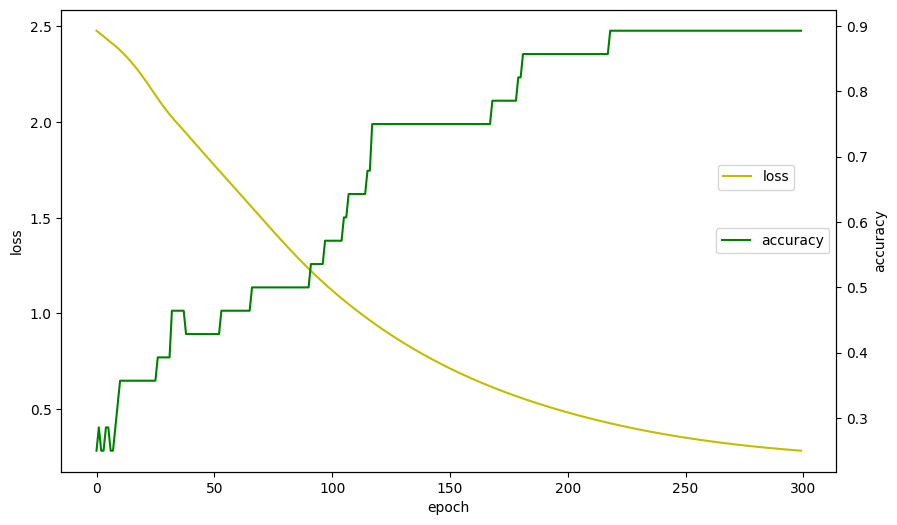

In [23]:
# 5 모델 평가하기
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [42]:
# 6. 모델 사용하기(경마장에 -> 있는)
encoded = t.texts_to_sequences(['경마장에'])[0]
input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')
result = model.predict(input_data).argmax()
print('모델 예측 결과 :', result)
for key, value in t.word_index.items():
    if value == result:
        print('예측한 단어 :', key)
        break

1/1 [==============================] - 0s 25ms/step
모델 예측 결과 : 3
예측한 단어 : 있는


In [39]:
t.texts_to_sequences(['없네'])[0]

[]

In [43]:
encoded = t.texts_to_sequences(['겨울은'])[0]
input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')
input_data

array([[0, 0, 0, 0, 0]])

In [58]:
# 6. 모델 사용하기(사용자로부터 입력받은 문자 -> ?)
word = input('입력단어는? ')
encoded = t.texts_to_sequences([word])[0]
input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')
result = model.predict(input_data).argmax()
print('모델 예측 결과 :', result)
for key, value in t.word_index.items():
    if value == result:
        print('예측한 단어 :', key)
        break

입력단어는 ?경마장에
1/1 [==============================] - 0s 15ms/step
모델 예측 결과 : 3
예측한 단어 : 있는


# 2. 다음 문맥 예측해 보기

In [83]:
# '경마장에' 이후에 단어 4개의 문맥을 만즐어줘
def sentence_generation(model, current_word,n):
    print('입력된 단어 :', current_word)
    for i in range(1, n+1):
        encoded = t.texts_to_sequences([current_word])
        input_data = pad_sequences(encoded, maxlen=my_len-1,padding = 'pre')
        result = model.predict(input_data, verbose=0).argmax()
        for word, index in t.word_index.items():
            if result == index:
                print("{}번째 예측 {} : {}".format(i, result, word))
                current_word = current_word + ' ' + word
                print("{}번째 예측 후 : {}".format(i, current_word))
                break
    #print('결과 :', current_word)

In [84]:
sentence_generation(model, '경마장에', 4)

입력된 단어 : 경마장에
1번째 예측 3 : 있는
1번째 예측 후 : 경마장에 있는
2번째 예측 1 : 말이
2번째 예측 후 : 경마장에 있는 말이
3번째 예측 4 : 뛰고
3번째 예측 후 : 경마장에 있는 말이 뛰고
4번째 예측 5 : 있다
4번째 예측 후 : 경마장에 있는 말이 뛰고 있다
